# Implementation of a Standard Autoencoder on FashionMNIST

This notebook implements a standard **Autoencoder (AE)** using PyTorch.

An Autoencoder is a type of unsupervised artificial neural network used to learn efficient data codings (representations) in a lower-dimensional space (latent space). It consists of two main components:
1. **Encoder**: Compresses the input data $x$ into a lower-dimensional representation $z$.
2. **Decoder**: Reconstructs the input data from the latent representation $z$, aiming to produce an output $\hat{x}$ that is as close to $x$ as possible.

We train this network on the **FashionMNIST** dataset, which consists of 28x28 grayscale images of 10 fashion categories.


### Install Dependencies (if needed)


In [16]:
# !pip install torchvision

## 1. Imports and Setup
We start by importing the necessary libraries including PyTorch, Torchvision (for dataset loading and transformations), Matplotlib (for visualization), and Scikit-learn (for dimensionality reduction via PCA).


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

## 2. Device Configuration
We configure the training device to use a GPU (`cuda`) if available, which significantly speeds up training compared to a CPU.


In [18]:
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 3. Dataset and DataLoader
We load the **FashionMNIST** dataset and normalize the image pixels to the range $[0, 1]$ using `transforms.ToTensor()`. We set up a `DataLoader` to feed the data in mini-batches.


In [19]:
BATCH_SIZE = 64

data_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(root = "./data", train = True, transform = data_transform, download = True)

train_loader = DataLoader(train_dataset ,  batch_size = BATCH_SIZE, shuffle = True)

100%|██████████| 26.4M/26.4M [01:38<00:00, 267kB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 94.3kB/s]
100%|██████████| 4.42M/4.42M [00:15<00:00, 294kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 6.12MB/s]


## 4. Autoencoder Architecture
Here, we define the `AutoEncoder` model.
* **Encoder**: Consists of fully-connected layers mapping from $784 \to 256 \to \text{latent\_dim}$ with ReLU activation functions.
* **Decoder**: Consists of fully-connected layers mapping from $\text{latent\_dim} \to \text{hidden\_dim} \to 784$ with a Sigmoid activation function at the output layer to ensure pixel values are in $[0, 1]$.


In [20]:
#Define Auto encoder

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        #Encoder

        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
            nn.ReLU(),
        )

        #Decoder

        self.decoder  = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 784),
            nn.Sigmoid()

        )


    def forward(self, x):

        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

## 5. Hyperparameters and Optimization Setup
We specify the latent space dimension (64) and the hidden dimension (256). We initialize the model, define the **Mean Squared Error (MSE)** loss as our reconstruction criterion, and configure the **Adam** optimizer.

The reconstruction loss is defined as:
$$\mathcal{L}_{\text{MSE}}(x, \hat{x}) = \frac{1}{N} \sum_{i=1}^N (x_i - \hat{x}_i)^2$$


In [21]:
latent_dim = 64
hidden_dim = 256

#Defining the model, loss

model = AutoEncoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

## 6. Model Training
We train the autoencoder for 5 epochs. In each iteration, we flatten the 2D images into a 784-dimensional vector, pass them through the model, calculate the reconstruction loss, perform backpropagation, and update the model weights.


In [22]:
epochs = 5

model.train()

for epoch in range(epochs):
    total_loss = 0

    for x, _ in train_loader:
        x = x.view(-1, 784).to(device)

        optimizer.zero_grad()

        x_recon = model(x)

        loss = criterion(x_recon, x)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

Epoch 1/5, Loss: 0.026793088230775045
Epoch 2/5, Loss: 0.015209215117304692
Epoch 3/5, Loss: 0.012916917005168603
Epoch 4/5, Loss: 0.011629705979570207
Epoch 5/5, Loss: 0.010793188982990696


## 7. Reconstructed Image Visualization
To evaluate how well our model has learned to compress and reconstruct images, we pass a batch of test images through the autoencoder and compare the original images with their corresponding reconstructions.


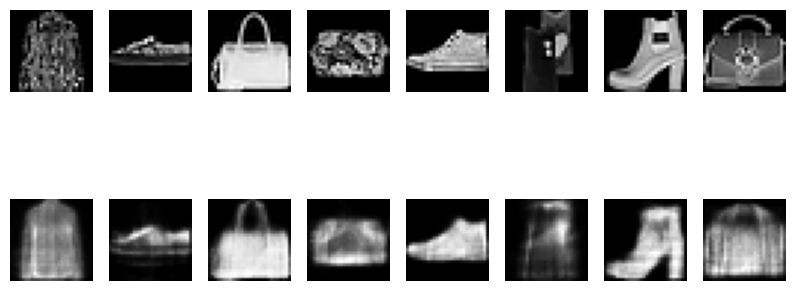

In [23]:
model.eval()

with torch.no_grad():

    x, _ = next(iter(train_loader))

    x = x.view(-1, 784).to(device)

    x_recon = model(x)

    # x = x.cpu()

    n = 8
    plt.figure(figsize = (10, 4.5))

    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(x[i].reshape(28, 28).cpu().numpy(), cmap = "gray")
        plt.axis("off")

        plt.subplot(2, n, i+1+n)
        plt.imshow(x_recon[i].reshape(28, 28).cpu().numpy(), cmap = "gray")
        plt.axis("off")

    plt.show()

## 8. Latent Space Visualization Helper
We define a utility function `visualize_latent_space` to plot the latent representations of the dataset. Since our latent space is high-dimensional (64D), we apply **Principal Component Analysis (PCA)** to project it down to a 2D space for visualization.


In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def visualize_latent_space(model, dataloader, device):
    model.eval()

    latents = []
    labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.view(x.size(0), -1).to(device)

            z = model.encoder(x)

            latents.append(z.cpu())
            labels.append(y)

    latents = torch.cat(latents, dim=0).numpy()
    labels = torch.cat(labels, dim=0).numpy()

    latent_dim = latents.shape[1]

    print(f"Latent Shape: {latents.shape}")

    # --------------------------------------------------
    # 1D Latent Space
    # --------------------------------------------------
    if latent_dim == 1:
        plt.figure(figsize=(8, 5))

        plt.hist(
            latents[:, 0],
            bins=50,
            alpha=0.8,
            edgecolor="black"
        )

        plt.title("1D Latent Distribution")
        plt.xlabel("Latent Value")
        plt.ylabel("Frequency")
        plt.show()

    # 2D Latent Space

    elif latent_dim == 2:
        plt.figure(figsize=(8, 6))

        scatter = plt.scatter(
            latents[:, 0],
            latents[:, 1],
            c=labels,
            cmap="tab10",
            s=10,
            alpha=0.7
        )

        plt.colorbar(scatter)
        plt.title("2D Latent Space")
        plt.xlabel("z1")
        plt.ylabel("z2")
        plt.show()

    # 3D Latent Space

    elif latent_dim == 3:
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection="3d")

        scatter = ax.scatter(
            latents[:, 0],
            latents[:, 1],
            latents[:, 2],
            c=labels,
            cmap="tab10",
            s=10,
            alpha=0.7
        )

        fig.colorbar(scatter)

        ax.set_title("3D Latent Space")
        ax.set_xlabel("z1")
        ax.set_ylabel("z2")
        ax.set_zlabel("z3")

        plt.show()

    # Higher Dimensions -> PCA -> 2D

    else:
        print(
            f"Latent dimension is {latent_dim}. "
            "Applying PCA → 2D..."
        )

        pca = PCA(n_components=2)
        latents_2d = pca.fit_transform(latents)

        explained = pca.explained_variance_ratio_.sum()

        plt.figure(figsize=(8, 6))

        scatter = plt.scatter(
            latents_2d[:, 0],
            latents_2d[:, 1],
            c=labels,
            cmap="tab10",
            s=10,
            alpha=0.7
        )

        plt.colorbar(scatter)

        plt.title(
            f"PCA Projection of Latent Space\n"
            f"Explained Variance: {explained:.2%}"
        )

        plt.xlabel("PC1")
        plt.ylabel("PC2")

        plt.show()

## 9. Visualizing the Learned Latent Representations
Now, we run the visualization function to see how the different FashionMNIST classes are clustered in the projected 2D latent space. Good clustering indicates that the encoder has learned meaningful semantic representations of the different clothing items.


Latent Shape: (60000, 64)
Latent dimension is 64. Applying PCA → 2D...


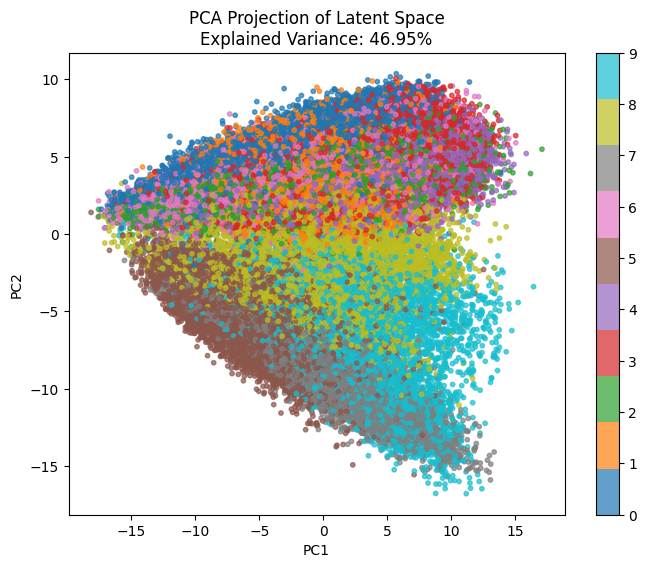

In [25]:
visualize_latent_space(
    model,
    train_loader,
    device
)

## 10. Generating New Samples from Latent Space
A standard Autoencoder is primarily a reconstruction model and lacks a smooth generative latent space. However, we can still sample a random vector from a normal distribution $\mathcal{N}(0, I)$, pass it through the decoder, and visualize the generated image.


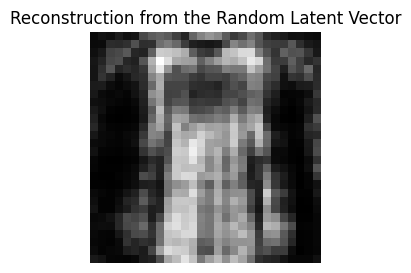

In [26]:
model.eval()

with torch.no_grad():

    latent_dim = model.encoder[-2].out_features
    z_random = torch.randn(1, latent_dim).to(device)

    x_generated = model.decoder(z_random)

    x_generated = x_generated.cpu().view(28, 28)

plt.figure(figsize = (3,3))
plt.imshow(x_generated, cmap = "gray")
plt.axis('off')
plt.title('Reconstruction from the Random Latent Vector')
plt.show()